In [ ]:
import numpy as np
import math
import librosa

In [ ]:
# Parameters
sr = 16000
frame_size = 0.025      # 25 ms
frame_stride = 0.010    # 10 ms
n_fft = 512
n_mels = 40
n_mfcc = 13
pre_emphasis = 0.97


In [ ]:
def pre_emphasis_signal(signal, alpha=0.97):
    emphasized = np.append(signal[0], signal[1:] - alpha * signal[:-1])
    return emphasized


In [ ]:
def framing(signal, sr, frame_size, frame_stride):
    frame_len = int(frame_size * sr)
    frame_step = int(frame_stride * sr)

    signal_len = len(signal)
    num_frames = int(np.ceil((signal_len - frame_len) / frame_step)) + 1

    pad_len = num_frames * frame_step + frame_len
    pad_signal = np.append(signal, np.zeros(pad_len - signal_len))

    indices = (
        np.tile(np.arange(frame_len), (num_frames, 1)) +
        np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_len, 1)).T
    )

    frames = pad_signal[indices]
    return frames


In [ ]:
def hamming_window(frames):
    N = frames.shape[1]
    window = 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(N) / (N - 1))
    return frames * window


In [ ]:
def power_spectrum(frames, n_fft):
    fft = np.fft.rfft(frames, n_fft)
    power = (1.0 / n_fft) * (np.abs(fft) ** 2)
    return power


In [ ]:
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10**(m / 2595) - 1)


In [ ]:
def mel_filterbank(n_mels, n_fft, sr):
    f_min = 0
    f_max = sr / 2

    mel_min = hz_to_mel(f_min)
    mel_max = hz_to_mel(f_max)

    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points = mel_to_hz(mel_points)

    bins = np.floor((n_fft + 1) * hz_points / sr).astype(int)

    fbanks = np.zeros((n_mels, n_fft // 2 + 1))

    for m in range(1, n_mels + 1):
        f_left = bins[m - 1]
        f_center = bins[m]
        f_right = bins[m + 1]

        for k in range(f_left, f_center):
            fbanks[m - 1, k] = (k - f_left) / (f_center - f_left)
        for k in range(f_center, f_right):
            fbanks[m - 1, k] = (f_right - k) / (f_right - f_center)

    return fbanks


In [ ]:
def log_mel_spectrum(power_spec, mel_fb):
    mel_energy = np.dot(power_spec, mel_fb.T)
    mel_energy = np.where(mel_energy == 0, np.finfo(float).eps, mel_energy)
    return np.log(mel_energy)


In [ ]:
def dct_type_2(log_mel, n_mfcc):
    M = log_mel.shape[1]
    mfcc = np.zeros((log_mel.shape[0], n_mfcc))

    for n in range(n_mfcc):
        for m in range(M):
            mfcc[:, n] += log_mel[:, m] * np.cos(
                np.pi * n * (m + 0.5) / M
            )

    return mfcc


In [ ]:
def mfcc(signal, sr):
    signal = pre_emphasis_signal(signal)

    frames = framing(signal, sr, frame_size, frame_stride)
    frames = hamming_window(frames)

    power_spec = power_spectrum(frames, n_fft)

    mel_fb = mel_filterbank(n_mels, n_fft, sr)
    log_mel = log_mel_spectrum(power_spec, mel_fb)

    mfcc_feat = dct_type_2(log_mel, n_mfcc)

    return mfcc_feat


In [ ]:
non_speech_mix, sr_1 = librosa.load("C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/non_speech_mix.wav")
non_speech, sr_2 = librosa.load("C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/non_speech.wav")
speech_mix, sr_3 = librosa.load('C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/speech_mix.wav')
speech, sr_4 = librosa.load('C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/speech.wav')

In [ ]:

n_sp_m_feature = mfcc(non_speech_mix[3 * sr:sr * 4], sr_1)
n_sp_feature = mfcc(non_speech[:sr * 1], sr_2)
sp_m_feature = mfcc(speech_mix[sr * 1:sr * 2], sr_3)
sp_feature = mfcc(speech[:sr * 1], sr_4)
print(n_sp_m_feature.shape)

(72, 13)


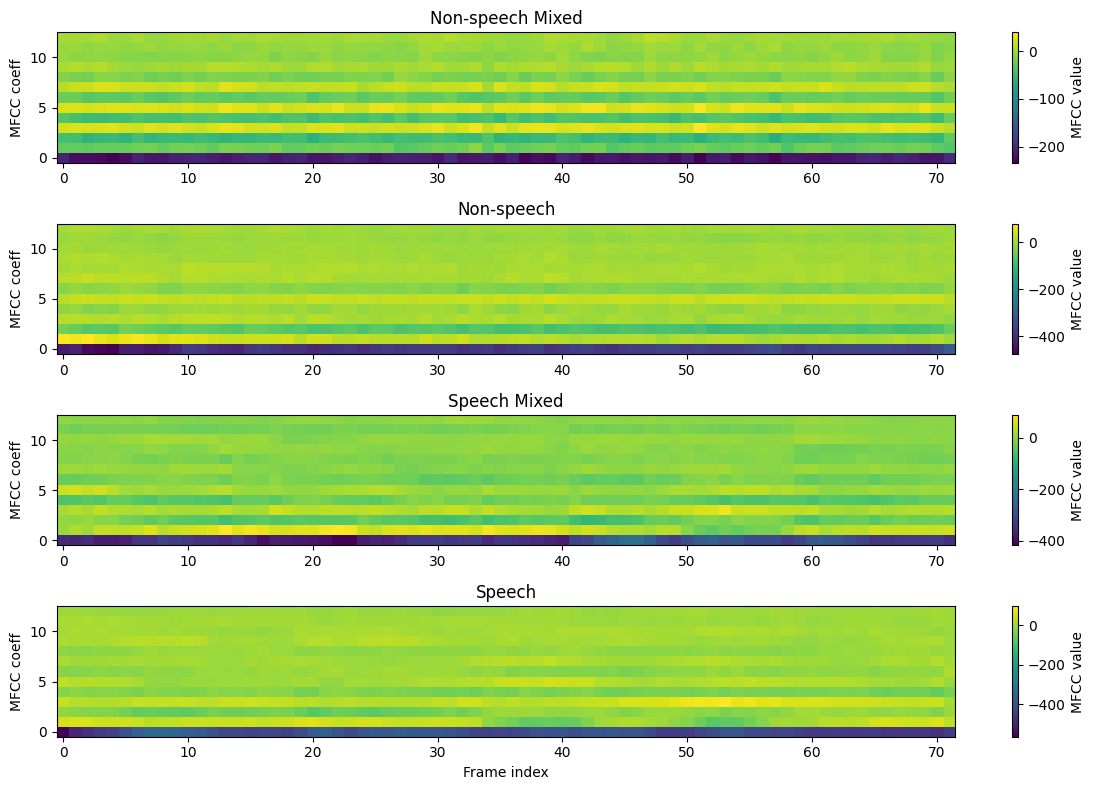

In [ ]:
import matplotlib.pyplot as plt

mfcc_list = [n_sp_m_feature, n_sp_feature, sp_m_feature, sp_feature]
titles = ['Non-speech Mixed', 'Non-speech', 'Speech Mixed', 'Speech']

plt.figure(figsize=(12, 8))

for i, mfcc in enumerate(mfcc_list):
    plt.subplot(4, 1, i + 1)
    plt.imshow(mfcc.T, aspect='auto', origin='lower')
    plt.colorbar(label='MFCC value')
    plt.ylabel('MFCC coeff')
    plt.title(titles[i])

plt.xlabel('Frame index')
plt.tight_layout()
plt.show()


In [ ]:
import librosa
import numpy as np

def mfcc_librosa(signal, fs,
                 n_mfcc=13,
                 n_fft=512,
                 hop_length=int(0.01 * fs),
                 win_length=int(0.025 * fs)):

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=fs,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window='hamming'
    )

    return mfcc.T  # (num_frames, 13)
f1 = mfcc(non_speech_mix, 16000)
f2 = mfcc(non_speech_mix, 16000)
print(f1, f2)
from numpy.linalg import norm

def cosine_distance(f1, f2):
    return norm(f1-f2)

print(cosine_distance(f1[0], f2[0]))